# 🧬 NLP — Named Entity Recognition (NER) with BC5CDR (Chemical & Disease Entities)

- 📌 **What is NER?**

Named Entity Recognition (NER) is a foundational task in Natural Language Processing (NLP) that involves identifying and classifying specific spans of text into predefined categories, such as person names, organizations, or locations. In biomedical applications, NER typically focuses on domain-specific entities such as diseases, chemicals, or genes.

- ⭐️ **Project Objective**

This notebook demonstrates a biomedical NER workflow using the **BioCreative V Chemical-Disease Relation (BC5CDR) Corpus**. The goal is to extract **both chemical and disease named entities** from PubMed abstracts using a token classification model. This is a fundamental step in automating information extraction for:

    - Chemical-induced disease (CID) relation analysis
    - Biomedical knowledge graph construction
    - Drug safety and toxicology mining
    - Literature curation for clinical research

- 🧠 **Task Setup**

    - **Task Type**: Token-level sequence labeling
    - **Entity Types**: Two entity classes → `Chemical`, `Disease`
    - **Dataset**: BioCreative V Chemical-Disease Relation Task Corpus (BC5CDR)  
      - 🔸 Designed for disease NER (DNER) and chemical–disease relation (CID) extraction  
      - 🔸 Contains 1,500 manually annotated PubMed abstracts  
      - 🔸 Split: 500 (train) / 500 (validation) / 500 (test)  
      - 🔗 [Paper](https://pubmed.ncbi.nlm.nih.gov/27161011/): *"BioCreative V CDR task corpus: a resource for chemical disease relation extraction"*

## Dataset load

In [1]:
import random
import numpy as np
import torch
from datasets import load_dataset, ClassLabel, Sequence
from transformers import set_seed, AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification, EarlyStoppingCallback

SEED = 44
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

In [2]:
ds = load_dataset("bigbio/bc5cdr", split="train", trust_remote_code=True)
ds.shape

(500, 1)

## BIO Labels
```
{'passages': [{'document_id': '227508',
   'type': 'title',
   'text': 'Naloxone reverses the antihypertensive effect of clonidine.',
   'entities': [{'id': '0',
     'offsets': [[0, 8]],
     'text': ['Naloxone'],
     'type': 'Chemical',
     'normalized': [{'db_name': 'MESH', 'db_id': 'D009270'}]},
    {'id': '1',
     'offsets': [[49, 58]],
     'text': ['clonidine'],
     'type': 'Chemical',
     'normalized': [{'db_name': 'MESH', 'db_id': 'D003000'}]}],
   'relations': [{'id': 'R0',
     'type': 'CID',
     'arg1_id': 'D008750',
     'arg2_id': 'D007022'}]},
```
the useful info: `text`, `offsets`, `type`

In [3]:
labels = ['O', 'B-Chemical', 'I-Chemical', 'B-Disease', 'I-Disease']
labels2id = {l:i for i, l in enumerate(labels)}
id2labels = {i:l for l,i in labels2id.items()}

### text.split() ❌

In [4]:
def preprocess_bio(ds):
    results = []
    for passage in ds['passages']:
        text = passage['text']
        entities = passage.get('entities')
        
        #init character-level labels to match offsets
        char_labels = ['O'] * len(text)
        for ent in entities:
            for start, end in ent['offsets']:
                char_labels[start] = f'B-{ent["type"]}'
                for i in range(start+1, end):
                    char_labels[i] = f'I-{ent["type"]}'

        tokens, offsets=[],[]
        cursor=0
        for token in text.split():
            start = text.find(token, cursor)
            end = start + len(token)
            tokens.append(token)
            offsets.append((start, end))
            cursor = end

        ner_tags=[]
        for start, end in offsets:
            span_labels = set(char_labels[start:end])
            tag = next((t for t in labels if t in span_labels),'O')
            ner_tags.append(labels2id[tag])

        results.append({
            'tokens': tokens,
            'ner_tags':ner_tags
        })

        return results

In [5]:
sample=ds[0]
output = preprocess_bio(sample)
print(output)

[{'tokens': ['Naloxone', 'reverses', 'the', 'antihypertensive', 'effect', 'of', 'clonidine.'], 'ner_tags': [1, 0, 0, 0, 0, 0, 0]}]


**Problems:**
Looks good, but the tokens use the `.split()` will lead to errors!
- For example, the last token `clonidine.` includes `.` , whereas it should be an chemical entity which failed to recognize because the offset cannot match.
- If I manually delete the punctuations will lead to not-match problem with 'offsets' of original text.
- Therefore: no modification on punctuations + the BIO should match with offsets -> Tokenization by 'BioBERT'

### Tokenizer ✅

- `bioBERT` model - better in domain area (bio/chemical)
  - search in huggingface, find one
- why not BERT? It's more common model which may perform poor in specific areas.

In [6]:
from transformers import AutoTokenizer
model_name = "dmis-lab/biobert-base-cased-v1.2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [7]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        [p[0]['text'] for p in examples['passages']],
        return_offsets_mapping=True,
        padding=False,
        truncation=True,
        is_split_into_words=False
    )
    all_labels = []
    for i, passage in enumerate(examples['passages']):
        text = passage[0]['text']
        entities = passage[0].get('entities', [])
        char_labels = ['O'] * len(text)
        for ent in entities:
            for start, end in ent['offsets']:
                char_labels[start] = f'B-{ent["type"]}'
                for j in range(start+1, end):
                    char_labels[j] = f'I-{ent["type"]}'
        labels = []
        for (start, end) in tokenized_inputs['offset_mapping'][i]:
            if start == end:
                labels.append(-100)
            else:
                tag = char_labels[start]
                labels.append(labels2id.get(tag, 0))
        all_labels.append(labels)
    tokenized_inputs["labels"] = all_labels
    return tokenized_inputs

In [8]:
tokenized_ds = ds.map(tokenize_and_align_labels, batched=True, remove_columns=["passages"])

In [9]:
#Check what tokens are
sample = ds[0]
tokenized = tokenizer(
    sample['passages'][0]['text'],
    return_offsets_mapping=True,
    truncation=False,
    padding=False
)
print("text:",sample['passages'][0]['text'])
print("---")
print("tokens:",tokenized.tokens())
print("---")
print("tokenized offsets:",tokenized['offset_mapping'])
print("---")
print("tokenized labels:",tokenized_ds[0]['labels'])

text: Naloxone reverses the antihypertensive effect of clonidine.
---
tokens: ['[CLS]', 'na', '##lo', '##xon', '##e', 'reverse', '##s', 'the', 'anti', '##hy', '##pert', '##ens', '##ive', 'effect', 'of', 'c', '##lon', '##id', '##ine', '.', '[SEP]']
---
tokenized offsets: [(0, 0), (0, 2), (2, 4), (4, 7), (7, 8), (9, 16), (16, 17), (18, 21), (22, 26), (26, 28), (28, 32), (32, 35), (35, 38), (39, 45), (46, 48), (49, 50), (50, 53), (53, 55), (55, 58), (58, 59), (0, 0)]
---
tokenized labels: [-100, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 0, -100]


## Train/Valid dataset

In [10]:
t_ds = load_dataset("bigbio/bc5cdr", split="test", trust_remote_code=True)
test_ds = t_ds.map(tokenize_and_align_labels, batched=True, remove_columns=["passages"])
v_ds = load_dataset("bigbio/bc5cdr", split="validation", trust_remote_code=True)
valid_ds = v_ds.map(tokenize_and_align_labels, batched=True, remove_columns=["passages"])

## Model training

In [11]:
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label=id2labels,
    label2id=labels2id
)

/Users/applewang/miniconda3/envs/fastai/lib/python3.11/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Data collator
`DataCollatorForTokenClassification`: used in `Trainer` parameter `data_collator=data_collator`, a key tool to manage `padding`, ensure the encoded labels matching with the inputs avoiding errors in specific tasks, such as NER, word-class sentiment analysis, POS tagging, etc.

In [12]:
data_collator = DataCollatorForTokenClassification(tokenizer)

## Metrics
`seqeval` package is designed for NER task's token-level classification_report, f1_score...

In [13]:
import numpy as np
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report

In [14]:
def compute_metrics(outputs):
    predictions, labels = outputs
    preds = np.argmax(predictions, axis=2)
    true_labels = [[id2labels[label_id] for label_id in label if label_id != -100] for label in labels]
    true_preds = [[id2labels[pred_id] for pred_id, label_id in zip(pred, label) if label_id != -100] for (pred, label) in zip(preds, labels)]

    return {
        "precision": precision_score(true_labels, true_preds),
        "recall": recall_score(true_labels, true_preds),
        "f1_score":f1_score(true_labels, true_preds),
        "classification_report": classification_report(true_labels, true_preds)
    }

## Training

In [15]:
train_args = TrainingArguments(output_dir='./009_ner_outputs',
                              eval_strategy='epoch',
                              save_strategy='epoch',
                               logging_strategy='epoch',
                               logging_dir='./009_ner_logs',
                               learning_rate=2e-5,
                               warmup_ratio=0.1,
                               fp16=False, 
                               bf16=False,
                               per_device_train_batch_size=8,
                               per_device_eval_batch_size=8,
                               num_train_epochs=5,
                               weight_decay=0.02,
                               load_best_model_at_end=True,
                               metric_for_best_model="f1_score",
                               save_total_limit=2,
                               report_to='tensorboard'
                              )

### callbacks

In [16]:
cbs = EarlyStoppingCallback(early_stopping_patience=3)

In [17]:
trainer = Trainer(model, 
                  args=train_args, 
                  train_dataset=tokenized_ds,
                  eval_dataset=valid_ds,
                  data_collator=data_collator,
                  compute_metrics=compute_metrics,
                  callbacks=[cbs]
                 )

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1 Score,Classification Report
1,0.503500,0.155487,0.765289,0.741393,0.753152,precision recall f1-score support Chemical 0.87 0.85 0.86 657 Disease 0.65 0.62 0.63 592 micro avg 0.77 0.74 0.75 1249 macro avg 0.76 0.74 0.75 1249 weighted avg 0.76 0.74 0.75 1249
2,0.106100,0.120718,0.805662,0.843074,0.823944,precision recall f1-score support Chemical 0.90 0.94 0.92 657 Disease 0.70 0.74 0.72 592 micro avg 0.81 0.84 0.82 1249 macro avg 0.80 0.84 0.82 1249 weighted avg 0.81 0.84 0.82 1249
3,0.050500,0.128637,0.842767,0.858287,0.850456,precision recall f1-score support Chemical 0.93 0.93 0.93 657 Disease 0.75 0.77 0.76 592 micro avg 0.84 0.86 0.85 1249 macro avg 0.84 0.85 0.85 1249 weighted avg 0.84 0.86 0.85 1249
4,0.031400,0.145667,0.823711,0.856685,0.839874,precision recall f1-score support Chemical 0.90 0.94 0.92 657 Disease 0.73 0.76 0.75 592 micro avg 0.82 0.86 0.84 1249 macro avg 0.82 0.85 0.84 1249 weighted avg 0.82 0.86 0.84 1249
5,0.018400,0.154429,0.819508,0.854283,0.836535,precision recall f1-score support Chemical 0.90 0.94 0.92 657 Disease 0.73 0.76 0.74 592 micro avg 0.82 0.85 0.84 1249 macro avg 0.81 0.85 0.83 1249 weighted avg 0.82 0.85 0.84 1249


TrainOutput(global_step=315, training_loss=0.14197711339072575, metrics={'train_runtime': 45.012, 'train_samples_per_second': 55.541, 'train_steps_per_second': 6.998, 'total_flos': 56274232494480.0, 'train_loss': 0.14197711339072575, 'epoch': 5.0})

### Evaluation

In [19]:
results = trainer.evaluate()

In [20]:
print(results['eval_classification_report'])

              precision    recall  f1-score   support

    Chemical       0.93      0.93      0.93       657
     Disease       0.75      0.77      0.76       592

   micro avg       0.84      0.86      0.85      1249
   macro avg       0.84      0.85      0.85      1249
weighted avg       0.84      0.86      0.85      1249



## Predict test_ds

In [21]:
outputs = trainer.predict(test_ds)

In [22]:
print(outputs.metrics['test_classification_report'])

              precision    recall  f1-score   support

    Chemical       0.91      0.92      0.92       667
     Disease       0.73      0.80      0.76       598

   micro avg       0.82      0.86      0.84      1265
   macro avg       0.82      0.86      0.84      1265
weighted avg       0.83      0.86      0.84      1265



## Conclusion

**Overall, the model is well-suited for biomedical named entity recognition (BioNER) tasks, and can serve as a reliable component for downstream applications in information extraction or biomedical text mining.**

- Validation -> Test Set Performance:
	- Chemical Entities: F1 = 0.93 -> 0.92
	- Disease Entities: F1 = 0.76 -> 0.76

These results indicate that the model demonstrates strong generalization ability across unseen data, with consistent F1-scores between validation and test sets. The performance on **Chemical entity** is particularly robust, while **Disease entity** recognition is comparatively lower, suggesting potential for further optimization in this category.

**Chemical entity is much robust than Disease entity with <u>no imbalance problems</u>, why?**

Two classes samples:
- Chemical: ~657 / 667 samples
- Disease: ~592 / 598 samples

Possible reasons:
- data itself: Chemical terms - more professional with fixed words; Disease terms - more common with vague phrases;
- BioBERT models leans towards chemical terms (pre-training in PubMed articles);
- Overlap of labels/polysemy -> greater impact on "Disease".



In [23]:
import numpy as np

preds = np.argmax(outputs.predictions, axis=2)

true_labels = [
    [id2labels[l] for (l, m) in zip(label, mask) if m != -100]
    for label, mask in zip(outputs.label_ids, outputs.label_ids)
]
true_predictions = [
    [id2labels[p] for (p, m) in zip(pred, mask) if m != -100]
    for pred, mask in zip(preds, outputs.label_ids)
]

In [24]:
#check test_ds #idx sample
idx = 12  
print("Text:", t_ds[idx]['passages'][0]['text'])
print("---")
print("Tokens:", tokenizer.convert_ids_to_tokens(test_ds[idx]["input_ids"]))
print("---")
print("Tokenized labels:", test_ds[idx]['labels'])
print("---")
print("True labels:", true_labels[idx])
print("---")
print("Pred labels:", true_predictions[idx])

Text: Risk factors and predictors of levodopa-induced dyskinesia among multiethnic Malaysians with Parkinson's disease.
---
Tokens: ['[CLS]', 'risk', 'factors', 'and', 'predict', '##ors', 'of', 'le', '##vo', '##do', '##pa', '-', 'induced', 'd', '##ys', '##kin', '##esi', '##a', 'among', 'multi', '##eth', '##nic', 'ma', '##lay', '##sian', '##s', 'with', 'park', '##ins', '##on', "'", 's', 'disease', '.', '[SEP]']
---
Tokenized labels: [-100, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 0, 0, 3, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 4, 4, 4, 4, 0, -100]
---
True labels: ['O', 'O', 'O', 'O', 'O', 'O', 'B-Chemical', 'I-Chemical', 'I-Chemical', 'I-Chemical', 'O', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O']
---
Pred labels: ['O', 'O', 'O', 'O', 'O', 'O', 'B-Chemical', 'I-Chemical', 'I-Chemical', 'I-Chemical', 'O', 'O', 'B-Disease', 'I-Disease', 'I-Di

## Tensorboard
Bash command: `tensorboard --load_fast=False --logdir ./009_ner_logs`

- **Training Convergence Summary**
As shown in the TensorBoard visualization, the model's validation F1-score steadily increased and plateaued around 0.836. Meanwhile, the validation loss exhibited a slight rise in the final epochs, which may suggest minor overfitting. However, since the F1-score did not drop, this checkpoint is considered sufficiently optimal for deployment or further fine-tuning.

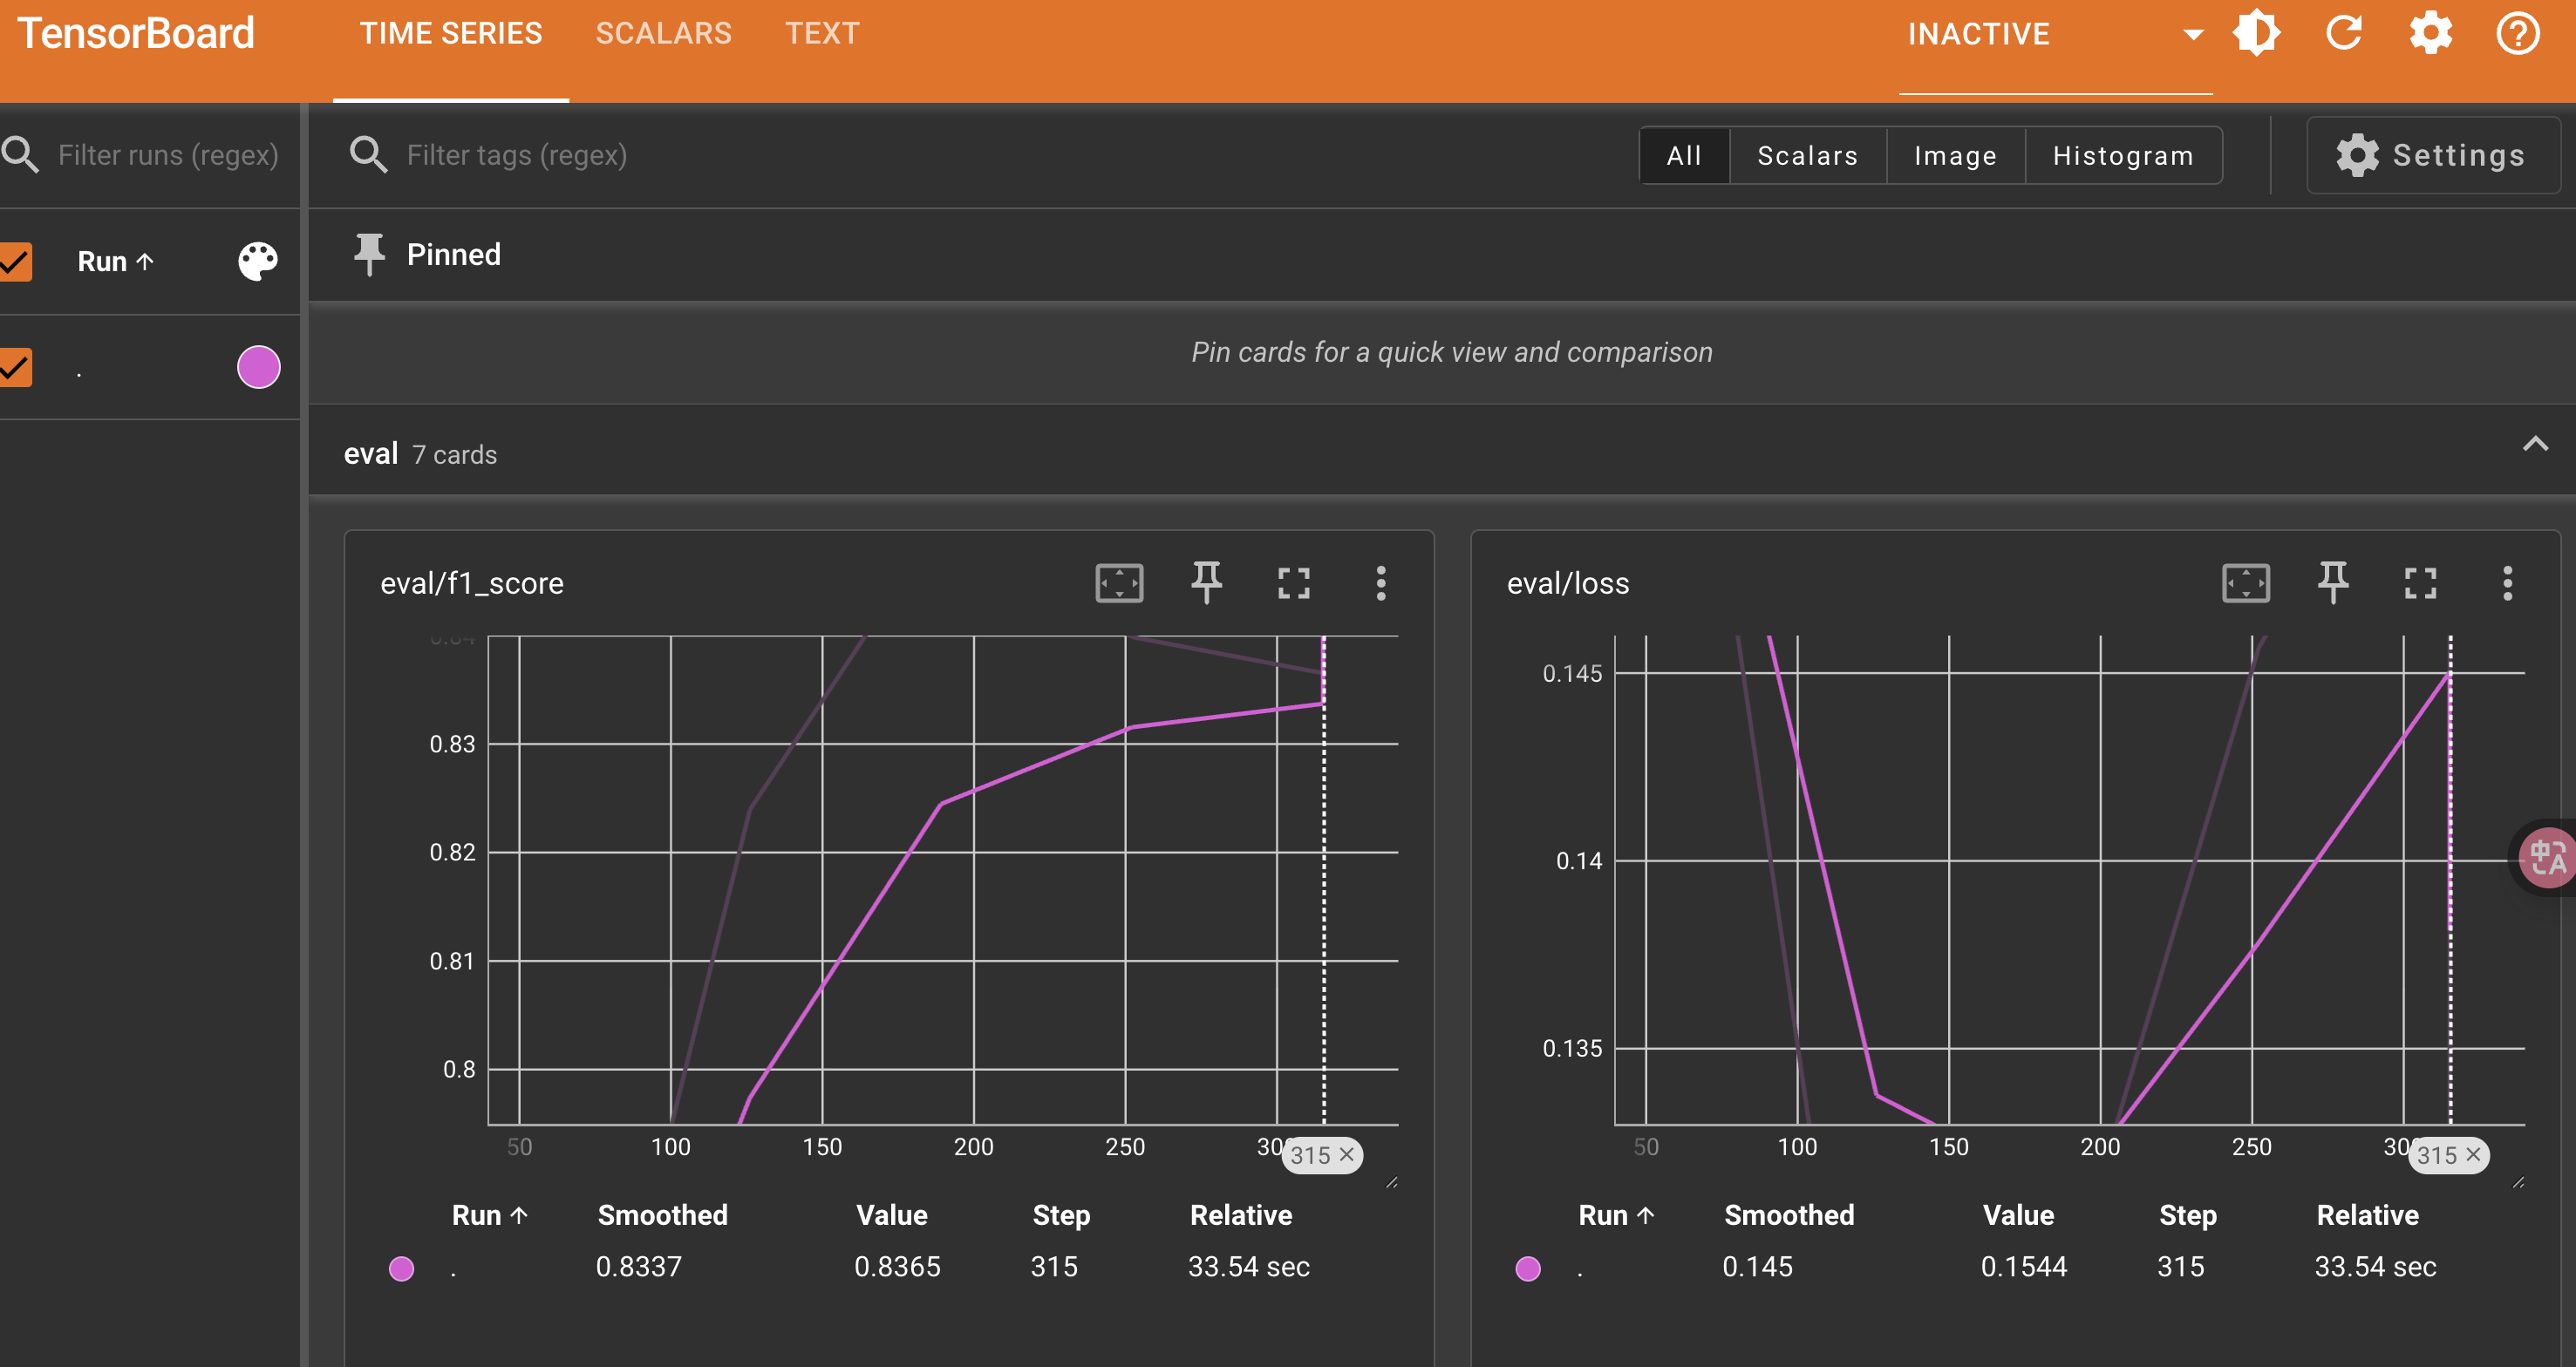

In [26]:
%load_ext tensorboard
%tensorboard --load_fast=false --logdir /Users/applewang/Desktop/Study_Materials_2023_2025/fastai_course/my-practice/009_ner_logs

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
